# Project: Carbon Emissions & Sustainability Analytics

This notebook demonstrates a complete workflow for **carbon emissions and sustainability analytics** using a sample dataset.

The project focuses on two main goals:
- analyzing emissions data
- predicting **CO₂ savings from renewables**

The dataset contains hourly values for:
- electricity demand
- solar generation
- wind generation
- fossil-based generation
- emission factors
- total CO₂ emissions

A **Linear Regression** model is used in this notebook. This model is simple, interpretable, and suitable for teaching because it shows clearly how the energy mix influences total emissions and CO₂ savings.

The notebook demonstrates a full carbon emissions and sustainability analytics workflow:
- loading and cleaning emissions-related data
- analyzing the energy mix and renewable share
- comparing actual emissions with a fossil-only reference scenario
- calculating CO₂ savings from renewables
- creating time-based features
- building a baseline prediction
- training a Linear Regression model
- evaluating and visualizing predictions
- performing a simple sustainability scenario analysis

## Step 1. Import the Python libraries

In this first step, the Python libraries that will be used throughout the notebook are imported. These libraries are needed for data manipulation, visualization, model training, and evaluation. The selected libraries are standard and widely used in practical data analysis and machine learning projects.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Step 2. Load the dataset

In this step, the sample CSV dataset is loaded. In real-world sustainability projects, emissions data may come from metering systems, renewable generation reports, grid operator data, or carbon accounting systems. Here, all relevant variables are stored in one dataset for simplicity.


In [3]:
BASE_URL = "https://raw.githubusercontent.com/tskaneva/bip_2026_big_data_and_ai_in_res/main/data"

df = pd.read_csv(f"{BASE_URL}/sample_carbon_emissions_sustainability_data.csv")


## Step 3. Display the first rows and basic information

In this step, the first rows and structural information of the dataset are displayed. This makes it possible to verify that the file was loaded correctly and to inspect the available columns and their data types.


In [4]:
print(df.head())
print(df.info())


             timestamp    load_kwh  solar_kwh   wind_kwh  fossil_kwh  \
0  2023-01-01 00:00:00  272.480293   1.092771  34.324036  237.063486   
1  2023-01-01 01:00:00  271.836551   0.000000  45.382689  226.453862   
2  2023-01-01 02:00:00  289.158523   1.424915  48.591794  239.141814   
3  2023-01-01 03:00:00  265.428268   3.350666  54.327926  207.749677   
4  2023-01-01 04:00:00  277.584994   0.000000  58.364179  219.220815   

   solar_emission_factor  wind_emission_factor  fossil_emission_factor  \
0                   0.02                  0.01                0.695249   
1                   0.02                  0.01                0.668040   
2                   0.02                  0.01                0.679456   
3                   0.02                  0.01                0.684991   
4                   0.02                  0.01                0.695348   

       co2_kg  
0  165.183163  
1  151.733996  
2  163.000772  
3  142.916883  
4  153.018368  
<class 'pandas.DataFrame'>

## Step 4. Convert the timestamp column to datetime format

In this step, the timestamp column is converted to datetime format. This is necessary because sorting, resampling, and creating time-based features depend on proper datetime values.


In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"])


## Step 5. Sort the dataset chronologically

In this step, the dataset is sorted by timestamp. Time-based datasets should always be in the correct chronological order before cleaning, visualization, or modeling.


In [6]:
df = df.sort_values("timestamp").reset_index(drop=True)


## Step 6. Remove duplicate timestamps

In this step, duplicate timestamp rows are removed. Duplicate entries can distort aggregations, plots, and the training of forecasting or regression models.


In [7]:
df = df.drop_duplicates(subset="timestamp")
print("Dataset shape after removing duplicates:", df.shape)


Dataset shape after removing duplicates: (2160, 9)


## Step 7. Check missing values

In this step, missing values are counted. Missing values are common in energy and sustainability datasets because of sensor issues, reporting delays, or incomplete measurements.


In [8]:
print(df.isna().sum())


timestamp                 0
load_kwh                  0
solar_kwh                 8
wind_kwh                  8
fossil_kwh                8
solar_emission_factor     0
wind_emission_factor      0
fossil_emission_factor    0
co2_kg                    8
dtype: int64


## Step 8. Set the timestamp as the index

In this step, the timestamp column is used as the index. This makes time-based operations such as resampling and plotting more convenient.


In [9]:
df = df.set_index("timestamp")


## Step 9. Resample the dataset to hourly frequency

In this step, the dataset is resampled to hourly frequency. The sample data is already hourly, but this step demonstrates a standard preprocessing operation used to guarantee consistent time intervals.


In [10]:
df = df.resample("h").mean()
print(df.head())


                       load_kwh  solar_kwh   wind_kwh  fossil_kwh  \
timestamp                                                           
2023-01-01 00:00:00  272.480293   1.092771  34.324036  237.063486   
2023-01-01 01:00:00  271.836551   0.000000  45.382689  226.453862   
2023-01-01 02:00:00  289.158523   1.424915  48.591794  239.141814   
2023-01-01 03:00:00  265.428268   3.350666  54.327926  207.749677   
2023-01-01 04:00:00  277.584994   0.000000  58.364179  219.220815   

                     solar_emission_factor  wind_emission_factor  \
timestamp                                                          
2023-01-01 00:00:00                   0.02                  0.01   
2023-01-01 01:00:00                   0.02                  0.01   
2023-01-01 02:00:00                   0.02                  0.01   
2023-01-01 03:00:00                   0.02                  0.01   
2023-01-01 04:00:00                   0.02                  0.01   

                     fossil_emission_fa

## Step 10. Handle missing values

In this step, missing values are handled using forward fill and backward fill. For time series energy data, this is often a practical approach because nearby values are usually more meaningful than a global average.


In [11]:
print("Missing values before filling:")
print(df.isna().sum())

df = df.ffill().bfill()

print("\nMissing values after filling:")
print(df.isna().sum())


Missing values before filling:
load_kwh                  0
solar_kwh                 8
wind_kwh                  8
fossil_kwh                8
solar_emission_factor     0
wind_emission_factor      0
fossil_emission_factor    0
co2_kg                    8
dtype: int64

Missing values after filling:
load_kwh                  0
solar_kwh                 0
wind_kwh                  0
fossil_kwh                0
solar_emission_factor     0
wind_emission_factor      0
fossil_emission_factor    0
co2_kg                    0
dtype: int64


## Step 11. Inspect the cleaned dataset

In this step, the cleaned dataset is displayed again. This confirms that the preprocessing steps have produced a consistent and usable dataset.


In [12]:
print(df.head())
print("\nFinal cleaned dataset shape:", df.shape)


                       load_kwh  solar_kwh   wind_kwh  fossil_kwh  \
timestamp                                                           
2023-01-01 00:00:00  272.480293   1.092771  34.324036  237.063486   
2023-01-01 01:00:00  271.836551   0.000000  45.382689  226.453862   
2023-01-01 02:00:00  289.158523   1.424915  48.591794  239.141814   
2023-01-01 03:00:00  265.428268   3.350666  54.327926  207.749677   
2023-01-01 04:00:00  277.584994   0.000000  58.364179  219.220815   

                     solar_emission_factor  wind_emission_factor  \
timestamp                                                          
2023-01-01 00:00:00                   0.02                  0.01   
2023-01-01 01:00:00                   0.02                  0.01   
2023-01-01 02:00:00                   0.02                  0.01   
2023-01-01 03:00:00                   0.02                  0.01   
2023-01-01 04:00:00                   0.02                  0.01   

                     fossil_emission_fa

## Step 12. Visualize the energy mix over time

In this step, the electricity demand and the different energy sources are plotted. This helps show how solar, wind, and fossil energy contribute to meeting the demand.


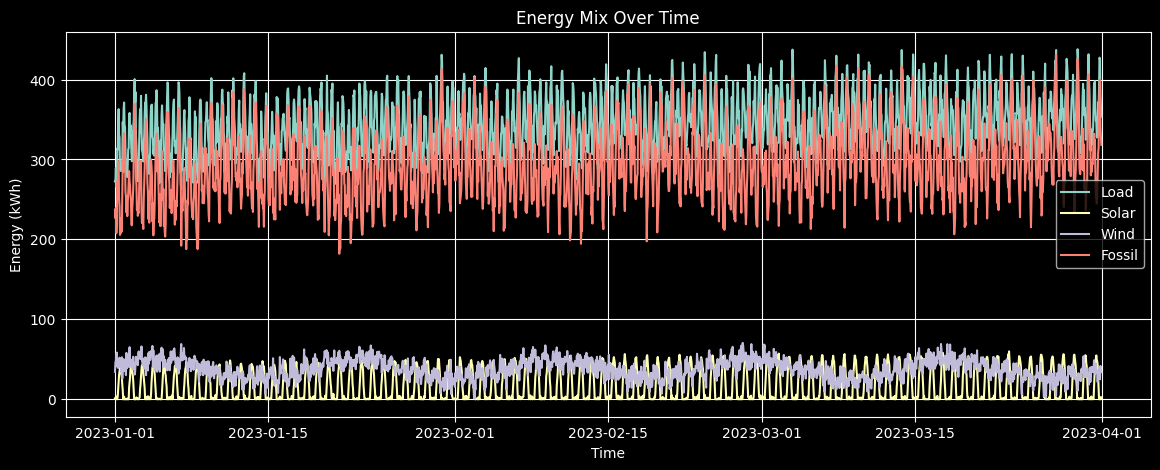

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["load_kwh"], label="Load")
plt.plot(df.index, df["solar_kwh"], label="Solar")
plt.plot(df.index, df["wind_kwh"], label="Wind")
plt.plot(df.index, df["fossil_kwh"], label="Fossil")
plt.title("Energy Mix Over Time")
plt.xlabel("Time")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(True)
plt.show()


## Step 13. Visualize total CO₂ emissions over time

In this step, total CO₂ emissions are plotted. Visual inspection helps identify temporal patterns, seasonal effects, and high-emission periods.


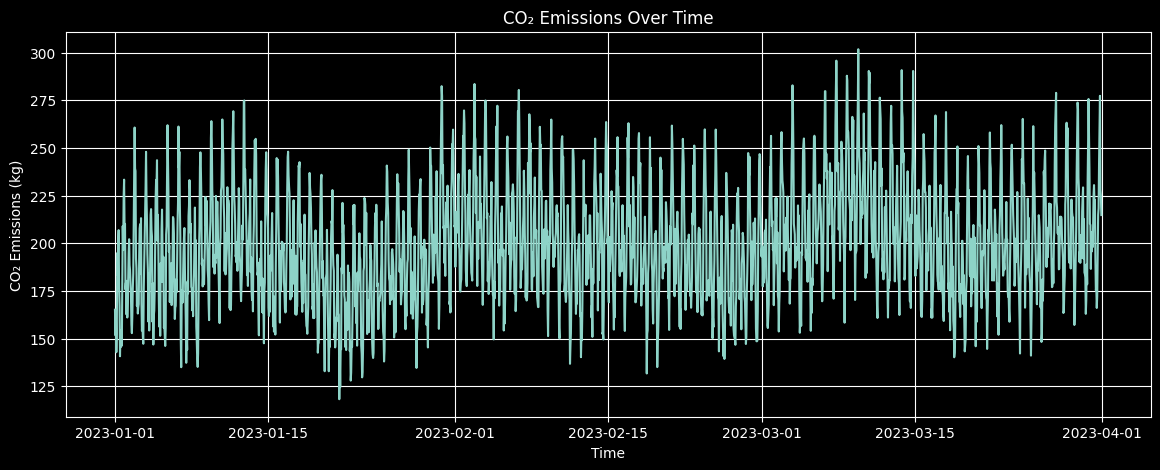

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["co2_kg"])
plt.title("CO₂ Emissions Over Time")
plt.xlabel("Time")
plt.ylabel("CO₂ Emissions (kg)")
plt.grid(True)
plt.show()


## Step 14. Calculate the renewable share

In this step, the share of renewable generation in the energy mix is calculated. This variable is important because a higher renewable share usually leads to lower carbon emissions.


In [15]:
df["renewable_kwh"] = df["solar_kwh"] + df["wind_kwh"]
df["renewable_share"] = df["renewable_kwh"] / df["load_kwh"]

print(df[["renewable_kwh", "renewable_share"]].head())


                     renewable_kwh  renewable_share
timestamp                                          
2023-01-01 00:00:00      35.416807         0.129979
2023-01-01 01:00:00      45.382689         0.166948
2023-01-01 02:00:00      50.016709         0.172973
2023-01-01 03:00:00      57.678591         0.217304
2023-01-01 04:00:00      58.364179         0.210257


## Step 15. Visualize renewable share over time

In this step, the renewable share is plotted. This helps show when the system is more dependent on renewables and when fossil backup becomes more important.


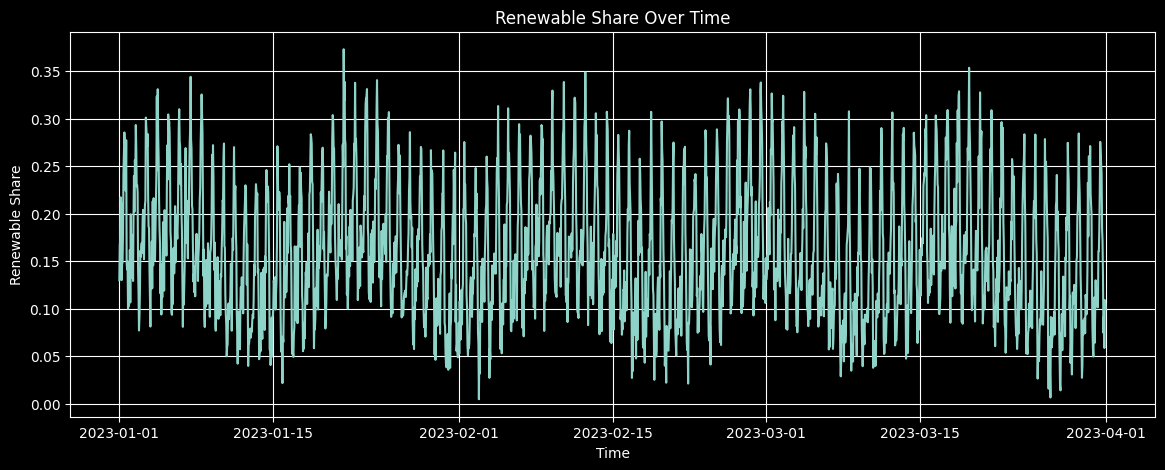

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["renewable_share"])
plt.title("Renewable Share Over Time")
plt.xlabel("Time")
plt.ylabel("Renewable Share")
plt.grid(True)
plt.show()


## Step 16. Build a reference scenario without renewables

In this step, a reference scenario is created where the full electricity demand is assumed to be covered by fossil generation only. This scenario is used as a baseline for estimating CO₂ savings from solar and wind.


In [17]:
df["co2_without_renewables"] = df["load_kwh"] * df["fossil_emission_factor"]
print(df[["load_kwh", "fossil_emission_factor", "co2_without_renewables"]].head())


                       load_kwh  fossil_emission_factor  \
timestamp                                                 
2023-01-01 00:00:00  272.480293                0.695249   
2023-01-01 01:00:00  271.836551                0.668040   
2023-01-01 02:00:00  289.158523                0.679456   
2023-01-01 03:00:00  265.428268                0.684991   
2023-01-01 04:00:00  277.584994                0.695348   

                     co2_without_renewables  
timestamp                                    
2023-01-01 00:00:00              189.441554  
2023-01-01 01:00:00              181.597607  
2023-01-01 02:00:00              196.470512  
2023-01-01 03:00:00              181.815888  
2023-01-01 04:00:00              193.018134  


## Step 17. Calculate CO₂ savings from renewables

In this step, CO₂ savings are computed as the difference between:
- emissions in the fossil-only reference scenario
- actual emissions in the mixed generation scenario

This provides a direct estimate of how much carbon is avoided because of renewable generation.


In [18]:
df["co2_savings_kg"] = df["co2_without_renewables"] - df["co2_kg"]

print(df["co2_savings_kg"].describe())


count    2160.000000
mean       36.186964
std        15.065653
min         1.298218
25%        24.526804
50%        33.886068
75%        47.548549
max        92.274730
Name: co2_savings_kg, dtype: float64


## Step 18. Visualize CO₂ savings over time

In this step, the CO₂ savings are plotted. This makes it possible to see when renewables provide the greatest environmental benefit.


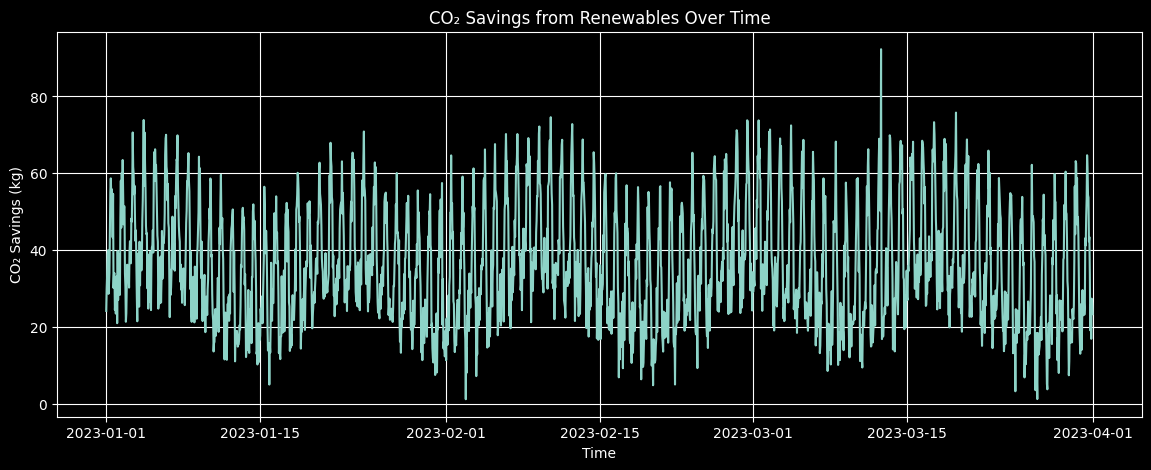

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["co2_savings_kg"])
plt.title("CO₂ Savings from Renewables Over Time")
plt.xlabel("Time")
plt.ylabel("CO₂ Savings (kg)")
plt.grid(True)
plt.show()


## Step 19. Compare emissions with and without renewables

In this step, the actual emissions are plotted together with the fossil-only reference scenario. This visual comparison makes the sustainability benefit of renewable generation easier to understand.


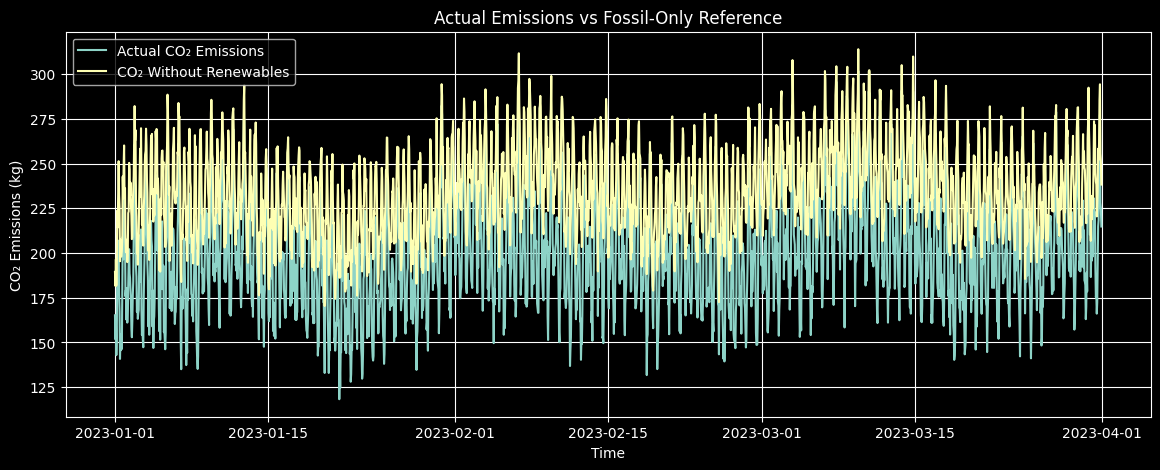

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["co2_kg"], label="Actual CO₂ Emissions")
plt.plot(df.index, df["co2_without_renewables"], label="CO₂ Without Renewables")
plt.title("Actual Emissions vs Fossil-Only Reference")
plt.xlabel("Time")
plt.ylabel("CO₂ Emissions (kg)")
plt.legend()
plt.grid(True)
plt.show()


## Step 20. Create time-based features

In this step, calendar-related features are extracted from the timestamp. Emissions and renewable output are often influenced by the hour of day, the day of week, and the month.


In [21]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)


## Step 21. Create cyclical time features

In this step, the hour and day-of-week features are converted into sine and cosine values. This is useful because time variables are cyclical and the cyclical encoding represents that repeating structure better than raw integer values.


In [22]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)


## Step 22. Define the model target

In this step, the prediction target is selected. The model will predict **CO₂ savings from renewables** because this is one of the main sustainability indicators in the project.


In [23]:
target_column = "co2_savings_kg"
print("Target column:", target_column)


Target column: co2_savings_kg


## Step 23. Define the model input features

In this step, the feature columns are selected. The inputs include energy generation values, demand, emission factors, renewable share, and time-based features.


In [24]:
feature_columns = [
    "load_kwh",
    "solar_kwh",
    "wind_kwh",
    "fossil_kwh",
    "solar_emission_factor",
    "wind_emission_factor",
    "fossil_emission_factor",
    "renewable_kwh",
    "renewable_share",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

X = df[feature_columns]
y = df[target_column]


## Step 24. Split the dataset chronologically

In this step, the dataset is split into training and testing sets in chronological order. This is appropriate for time-related sustainability data because future observations should not influence the earlier part of the analysis.

This notebook uses:
- 80% training data
- 20% testing data


In [25]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1728, 17)
Test shape: (432, 17)


## Step 25. Build a simple baseline prediction

In this step, a simple baseline is created. A practical baseline for CO₂ savings is to predict savings only from the renewable generation multiplied by the fossil emission factor. This provides a simple physics-inspired reference before using machine learning.


In [26]:
baseline_pred = (X_test["renewable_kwh"] * X_test["fossil_emission_factor"]).values


## Step 26. Evaluate the baseline prediction

In this step, the baseline is evaluated using standard regression metrics. These values provide a reference that the machine learning model should improve upon or at least match closely.


In [27]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print("-" * 30)

evaluate_model(y_test, baseline_pred, "Baseline Test Results")


Baseline Test Results
MAE  : 0.7801
RMSE : 1.1578
R²   : 0.9947
------------------------------


## Step 27. Train the Linear Regression model

In this step, a Linear Regression model is trained. This model is suitable here because it is easy to interpret and makes it possible to show how each variable contributes to predicted CO₂ savings.


In [28]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 28. Make predictions on the test set

In this step, the trained model predicts CO₂ savings for the test set.


In [29]:
test_pred = model.predict(X_test)


## Step 29. Evaluate the Linear Regression model

In this step, the machine learning model is evaluated using the same metrics as the baseline. This makes the comparison fair and easy to interpret.


In [30]:
evaluate_model(y_test, test_pred, "Linear Regression Test Results")


Linear Regression Test Results
MAE  : 0.6041
RMSE : 1.0545
R²   : 0.9956
------------------------------


## Step 30. Visualize actual and predicted CO₂ savings

In this step, the actual and predicted CO₂ savings are plotted for part of the test period. This helps assess whether the model follows the real trend and magnitude of the savings values.


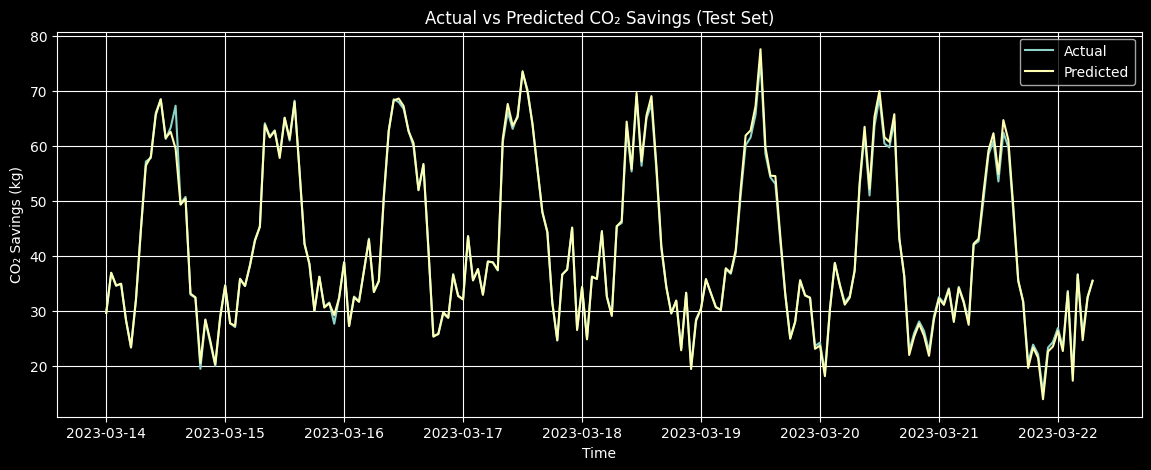

In [31]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index[:200], y_test.iloc[:200], label="Actual")
plt.plot(y_test.index[:200], test_pred[:200], label="Predicted")
plt.title("Actual vs Predicted CO₂ Savings (Test Set)")
plt.xlabel("Time")
plt.ylabel("CO₂ Savings (kg)")
plt.legend()
plt.grid(True)
plt.show()


## Step 31. Compare the baseline and the Linear Regression model

In this step, the baseline and the machine learning model are plotted together. This provides a direct visual comparison between the simple reference calculation and the learned regression model.


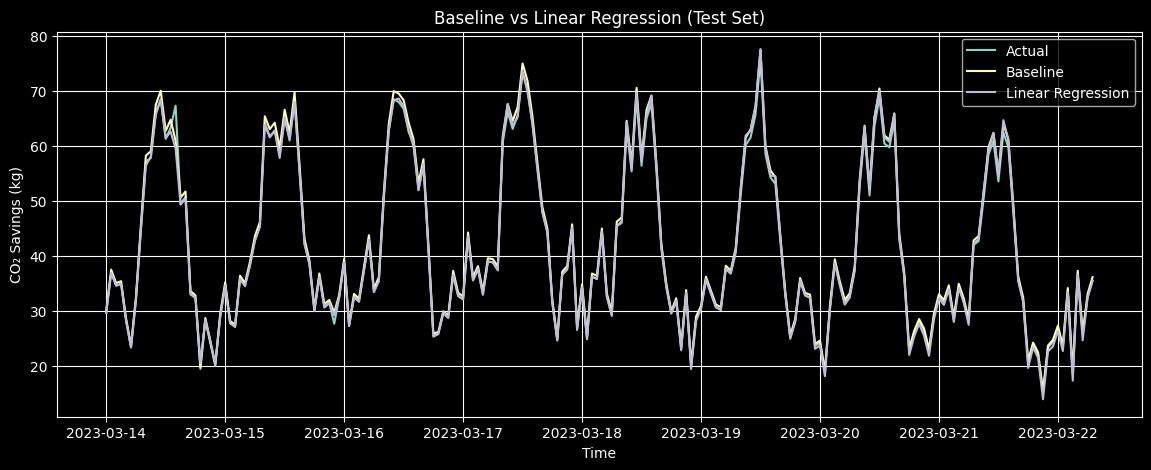

In [32]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index[:200], y_test.iloc[:200], label="Actual")
plt.plot(y_test.index[:200], baseline_pred[:200], label="Baseline")
plt.plot(y_test.index[:200], test_pred[:200], label="Linear Regression")
plt.title("Baseline vs Linear Regression (Test Set)")
plt.xlabel("Time")
plt.ylabel("CO₂ Savings (kg)")
plt.legend()
plt.grid(True)
plt.show()


## Step 32. Display the model coefficients

In this step, the Linear Regression coefficients are displayed. These values help explain how the input variables influence predicted CO₂ savings.


In [33]:
coef_df = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

print(coef_df)


                   Feature   Coefficient
6   fossil_emission_factor  5.651312e+01
7            renewable_kwh  4.226286e-01
2                 wind_kwh  2.146055e-01
1                solar_kwh  2.080230e-01
16                 dow_cos  1.015292e-01
10             day_of_week  7.080725e-02
0                 load_kwh  3.757841e-02
11                   month  2.860680e-02
4    solar_emission_factor  1.572110e-13
5     wind_emission_factor -1.344480e-13
9                     hour -8.712638e-03
15                 dow_sin -8.973798e-03
3               fossil_kwh -3.771785e-02
14                hour_cos -7.177754e-02
13                hour_sin -8.149387e-02
12              is_weekend -1.102580e-01
8          renewable_share -1.951345e+00


## Step 33. Visualize the model coefficients

In this step, the regression coefficients are plotted. This makes the interpretation of the model easier and helps show which variables contribute positively or negatively to CO₂ savings.


<Figure size 1000x600 with 0 Axes>

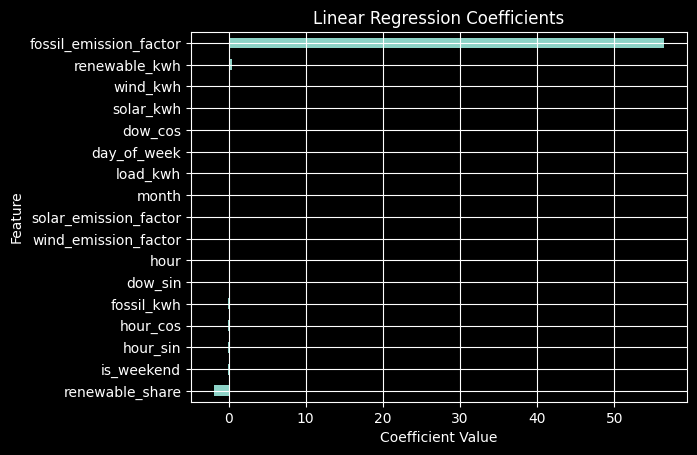

In [34]:
plt.figure(figsize=(10, 6))
coef_df.sort_values("Coefficient").plot(x="Feature", y="Coefficient", kind="barh", legend=False)
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.grid(True)
plt.show()


## Step 34. Calculate MAPE as an additional metric

In this step, the mean absolute percentage error is calculated. This expresses the prediction error in percentage terms. A small constant is added to avoid division by zero.


In [35]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    epsilon = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

mape_test = mean_absolute_percentage_error(y_test, test_pred)
print(f"Test MAPE: {mape_test:.2f}%")


Test MAPE: 3.63%


## Step 35. Perform a simple scenario analysis

In this step, a scenario is created where solar generation is increased by 20%. The trained model is then used to estimate how the predicted CO₂ savings would change. This is useful because sustainability analysis often includes what-if scenarios.


In [ ]:
scenario_df = X_test.copy()
scenario_df["solar_kwh"] = scenario_df["solar_kwh"] * 1.20
scenario_df["renewable_kwh"] = scenario_df["solar_kwh"] + scenario_df["wind_kwh"]
scenario_df["renewable_share"] = scenario_df["renewable_kwh"] / scenario_df["load_kwh"]

scenario_pred = model.predict(scenario_df)

print("Average predicted CO₂ savings - original test set:", test_pred.mean())
print("Average predicted CO₂ savings - 20% more solar:", scenario_pred.mean())
print("Average improvement in predicted savings:", (scenario_pred.mean() - test_pred.mean()))


## Step 36. Save the prediction results to a CSV file

In this step, the actual values, the baseline predictions, and the Linear Regression predictions are saved to a CSV file. This is useful for reporting, external visualization, or further analysis.


In [36]:
results_df = pd.DataFrame({
    "timestamp": y_test.index,
    "actual_co2_savings_kg": y_test.values,
    "baseline_prediction": baseline_pred,
    "linear_regression_prediction": test_pred
})

results_df.to_csv("carbon_emissions_sustainability_results.csv", index=False)
print("Results saved to carbon_emissions_sustainability_results.csv")


Results saved to carbon_emissions_sustainability_results.csv
